In [107]:
%load_ext autoreload
%autoreload 2

import sys, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm
from collections import defaultdict 

sys.path.append(os.path.join(os.getcwd(), '../symlie'))
sys.path.append(os.path.join(os.getcwd(), '..'))
from symlie.misc.viz import plot2d

from symlie.misc.utils_results import pivot, assert_columns_same, get_and_check_Ps, stringify_dict, aggregate_dataset, plot_best, return_table, plot_pivot
from symlie.misc.wandb import update_results_df, get_inspect_df, get_inspectdev_df
from symlie.model.setup import load_P_pred

sys.path.append(os.path.join(os.getcwd(), '../sympdee/sympde/viz'))
from sympdee.sympde.viz.general_plots import savefig 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [109]:
RELOAD_DF = True

store_dir = '../store'
df_path = os.path.join(store_dir, 'combi_show_dev.csv')

if RELOAD_DF:
    df = get_inspectdev_df(tags = ['combi_show_dev'])
    df.to_csv(df_path, index=False)
else:
    df = pd.read_csv(df_path)


Retreiving wandb 5dzyo05o: 100%|██████████| 284/284 [05:19<00:00,  1.13s/it]


In [110]:
datasets = {
    'Sine 1D' : '../data/sine1d',
}

method_dict = {
    'train' : 'ELL',
    'analytic' : 'Analytic',
    'vanilla' : 'Vanilla',
    'emlp' : 'EMLP',
}

method_dict = defaultdict(lambda: None, method_dict)

    

In [111]:
d = df[df['data_dir'] == datasets['Sine 1D']]

d['method'] = d['tags'].apply(lambda x: ''.join([method_dict[x_i] for x_i in x if method_dict[x_i] is not None]))

columns = ['test_loss_y', 'max_epochs', 'method', 'n_train', 'seed', 'lr', 'bias']
cols_groupby = ['method', 'n_train']
loss = 'test_loss_y'
d = d[columns]

# d = d.dropna(subset=[loss]).reset_index(drop=True)

d

,test_loss_y,max_epochs,method,n_train,seed,lr,bias
0,0.143428,100,Vanilla,10000,3,0.001,False
1,0.140044,100,Vanilla,10000,3,0.010,False
2,0.229656,100,Vanilla,10000,3,0.100,False
3,0.146008,100,Vanilla,10000,2,0.001,False
4,0.141945,100,Vanilla,10000,2,0.010,False
...,...,...,...,...,...,...,...
279,0.129313,1000,ELL,10,1,0.001,True
280,0.256803,500,ELL,100,1,0.100,True
281,0.082867,500,ELL,100,1,0.010,True
282,0.134200,1000,ELL,10,1,0.100,True


In [121]:
ds = {'no_bias' : d[d['bias'] == False], 'bias' : d[d['bias'] == True]}

In [65]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import numpy as np

# # Your initial data
# data = {
#     'test_loss_y': [0.152086, 0.220647, 0.710930, 0.158088, 0.245650, 1.053287, 0.151082, 0.235562, 0.634491, None, 0.164170, 0.234140, None, 0.152648, 0.266311, None, 0.157487, 0.144740, 1.591808, 0.146655, 0.257266, 0.318439, 0.146349, 0.147134, 0.302818, 0.142546, 0.143804],
#     'max_epochs': [1000]*27,
#     'method': ['Vanilla']*9 + ['ELL']*6 + ['Analytic']*3 + ['ELL'] + ['Analytic']*3 + ['ELL'] + ['Analytic']*4,
#     'n_train': [1000, 100, 10, 1000, 100, 10, 1000, 100, 10, 1000, 100, 10, 1000, 100, 10, 1000, 100, 100, 10, 1000, 10, 10, 1000, 100, 10, 100, 1000],
#     'seed': [3, 3, 3, 2, 2, 2, 1, 1, 1, 3, 3, 3, 2, 2, 2, 1, 1, 2, 2, 2, 3, 1, 3, 3, 1, 1, 1]
# }

# # Learning rates
# learning_rates = [0.1, 0.01, 0.001]

# # Convert to DataFrame
# df = pd.DataFrame(data)

# # Create a new DataFrame to store data replicated for each learning rate
# new_df = pd.concat([df.assign(learning_rate=lr) for lr in learning_rates], ignore_index=True)

# # Compute mean and std deviation grouped by 'learning_rate', 'method', and 'n_train'
# grouped = new_df.groupby(['learning_rate', 'method', 'n_train'])
# means = grouped['test_loss_y'].mean().reset_index()
# std_devs = grouped['test_loss_y'].std().reset_index()

# # Plotting setup
# fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6), sharey=True)
# colors = {'Analytic': 'blue', 'ELL': 'green', 'Vanilla': 'red'}

# for ax, (lr, group) in zip(axes, means.groupby('learning_rate')):
#     for method, method_group in group.groupby('method'):
#         current_std_dev = std_devs[(std_devs['learning_rate'] == lr) & (std_devs['method'] == method)]['test_loss_y'].values
#         ax.errorbar(method_group['n_train'], method_group['test_loss_y'], yerr=current_std_dev, fmt='-o', label=method, color=colors[method])
#     ax.set_xscale('log')
#     ax.set_title(f'Learning Rate = {lr}')
#     ax.set_xlabel('Number of Training Examples (n_train)')
#     ax.legend(title='Method')

# axes[0].set_ylabel('Mean Test Loss (with error bars)')
# fig.suptitle('Mean Test Loss by Training Examples, Method, and Learning Rate with Standard Deviation')
# plt.tight_layout(rect=[0, 0.03, 1, 0.95])
# plt.show()


In [55]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import numpy as np

# # Original data
# data = {
#     'test_loss_y': [0.152086, 0.220647, 0.710930, 0.158088, 0.245650, 1.053287, 0.151082, 0.235562, 0.634491, None, 0.164170, 0.234140, None, 0.152648, 0.266311, None, 0.157487, 0.144740, 1.591808, 0.146655, 0.257266, 0.318439, 0.146349, 0.147134, 0.302818, 0.142546, 0.143804],
#     'max_epochs': [1000]*27,
#     'method': ['Vanilla']*9 + ['ELL']*6 + ['Analytic']*3 + ['ELL'] + ['Analytic']*3 + ['ELL'] + ['Analytic']*4,
#     'n_train': [1000, 100, 10, 1000, 100, 10, 1000, 100, 10, 1000, 100, 10, 1000, 100, 10, 1000, 100, 100, 10, 1000, 10, 10, 1000, 100, 10, 100, 1000],
#     'seed': [3, 3, 3, 2, 2, 2, 1, 1, 1, 3, 3, 3, 2, 2, 2, 1, 1, 2, 2, 2, 3, 1, 3, 3, 1, 1, 1]
# }

# # Learning rates
# learning_rates = [0.1, 0.01, 0.001]

# # Create DataFrame
# df = pd.DataFrame(data)

# # Create a new DataFrame with data replicated for each learning rate
# expanded_df = pd.concat([df.assign(learning_rate=lr) for lr in learning_rates], ignore_index=True)
# expanded_df.loc[(expanded_df['method'] == 'Vanilla') & (expanded_df['n_train'] == 1000) & (expanded_df['learning_rate'] == 0.1), 'test_loss_y'] = 0.0001

# # Compute means and standard deviations across seeds
# stats_df = expanded_df.groupby(['method', 'n_train', 'learning_rate']).agg({'test_loss_y': ['mean', 'std']}).reset_index()
# stats_df.columns = ['method', 'n_train', 'learning_rate', 'mean_loss', 'std_dev']

# # Find the minimum mean test_loss_y for each method and training size across different learning rates
# idx = stats_df.groupby(['method', 'n_train'])['mean_loss'].idxmin()
# best_results = stats_df.loc[idx].dropna()

# # Plotting
# fig, ax = plt.subplots(figsize=(10, 6))
# colors = {'Analytic': 'blue', 'ELL': 'green', 'Vanilla': 'red'}

# for method, group in best_results.groupby('method'):
#     ax.errorbar(group['n_train'], group['mean_loss'], yerr=group['std_dev'], fmt='-o', label=method, color=colors[method])

# ax.set_xscale('log')
# ax.set_xlabel('Number of Training Examples (n_train)')
# ax.set_ylabel('Best Mean Test Loss with Standard Deviation')
# ax.set_title('Best Mean Test Loss by Training Examples and Method')
# plt.legend(title='Method')
# plt.show()


In [122]:
def get_df_best(d):
    stats_df = d.groupby(['method', 'n_train', 'lr']).agg({'test_loss_y': ['mean', 'std']}).reset_index()
    stats_df.columns = ['method', 'n_train', 'lr', 'mean_loss', 'std_dev']

    idx = stats_df.groupby(['method', 'n_train'])['mean_loss'].idxmin()
    get_df_best = stats_df.loc[idx].reset_index(drop=True)
    return get_df_best

bias_keys = ['no_bias', 'bias']
d_bests = {bias_key : get_df_best(ds[bias_key]) for bias_key in bias_keys}

d_bests['bias']
d_bests['no_bias']

,method,n_train,lr,mean_loss,std_dev
0,Analytic,10,0.001,0.270327,0.047053
1,Analytic,100,0.010,0.144714,0.006617
2,Analytic,1000,0.001,0.146755,0.002465
3,Analytic,10000,0.001,0.143655,0.000383
4,ELL,10,0.001,0.290059,0.033765
5,ELL,100,0.001,0.154277,0.004365
6,ELL,1000,0.001,0.148106,0.003262
7,ELL,10000,0.001,0.144781,0.002010
8,EMLP,10,0.100,0.649946,0.002766
9,EMLP,100,0.010,0.576420,0.008089


In [116]:
colors = {'Analytic': 'C0', 'ELL': 'C1', 'Vanilla': 'C2', 'EMLP': 'C3'}

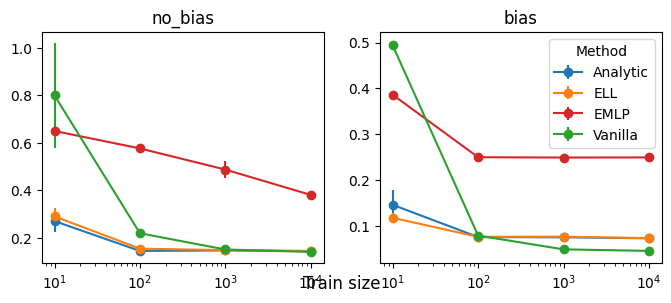

In [125]:
n_plots = len(d_bests)

fig, axes = plt.subplots(nrows=1, ncols=n_plots, figsize=(4*n_plots, 3), sharey=False)

for ax, (key, d_best) in zip(axes, d_bests.items()):
    for method, group in d_best.groupby('method'):
        ax.errorbar(group['n_train'], group['mean_loss'], yerr=group['std_dev'], fmt='-o', label=method, color=colors[method])
    ax.set_xscale('log')
    ax.set_title(f'{key}')
ax.legend(title='Method')
fig.supxlabel('Train size')

plt.show()

In [126]:
d_lrs = {bias_key : ds[bias_key].groupby('lr') for bias_key in bias_keys}
ds_plots = {bias_key: {lr: d_lr for lr, d_lr in d_lrs[bias_key]} for bias_key in bias_keys}


In [131]:
# d_lrs = {'no_bias': d_best_nobias, 'bias': d_best_bias}
# d_lrs = d_nobias.groupby('lr')
# d_best = d_nobias_best
# ds_plots = {lr : d_lr for lr, d_lr in d_lrs}

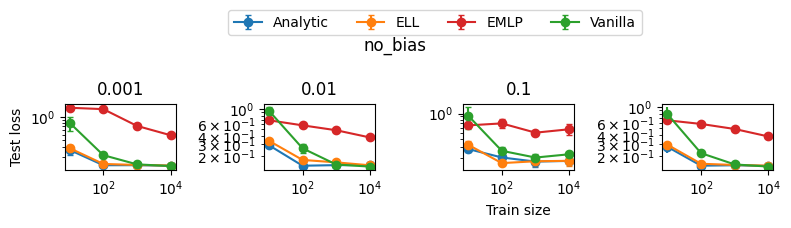

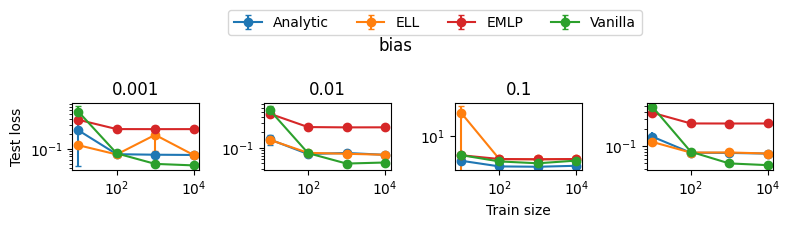

In [135]:

for bias_key, ds_plot in ds_plots.items():

    n_plot = len(ds_plot) + 1

    fig, axs = plt.subplots(ncols=n_plot, figsize=(2.*n_plot, 2.), tight_layout = True, sharex=True, sharey=False)

    colors = {'Analytic': 'C0', 'ELL': 'C1', 'Vanilla': 'C2', 'EMLP': 'C3'}

    handles, labels = [], []

    for i, ((title, d_plot), ax) in enumerate(zip(ds_plot.items(), axs)):
        # Compute mean and std deviation grouped by 'method' and 'n_train'
        grouped = d_plot.groupby(['method', 'n_train'])
        means = grouped['test_loss_y'].mean().reset_index()
        std_devs = grouped['test_loss_y'].std().reset_index()

        # Get the corresponding standard deviations for the group
        for method, group in means.groupby('method'):
            current_std_dev = std_devs[std_devs['method'] == method]['test_loss_y'].values
            ax.errorbar(group['n_train'], group['test_loss_y'], yerr=current_std_dev, fmt='-o', label=method, color=colors[method], capsize=2)

        ax.set_title(title) 

    ax = axs[-1]
    for method, group in d_bests[bias_key].groupby('method'):
        ax.errorbar(group['n_train'], group['mean_loss'], yerr=group['std_dev'], fmt='-o', label=method, color=colors[method])



    for ax in axs:

        ax.set_yscale('log')
        ax.set_xscale('log')  

        handles_ax, labels_ax = ax.get_legend_handles_labels()

        for handle, label in zip(handles_ax, labels_ax):
            if label not in labels:
                handles.append(handle)
                labels.append(label)

    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.55, 1.15), ncol = len(handles))

    axs[0].set_ylabel('Test loss')
    axs[n_plot//2].set_xlabel('Train size')
    # fig.supxlabel('Train size', x = 0.55)
    fig.suptitle(f'{bias_key}')
    fig.tight_layout()
    plt.show()

    # savefig(fig, 'implicit_results', '5-experiments', bbox_inches = 'tight')

